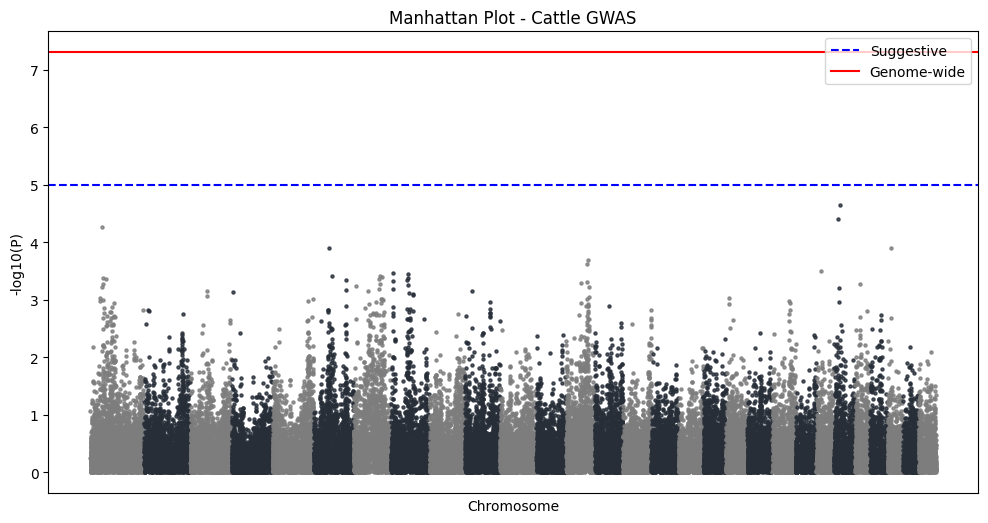

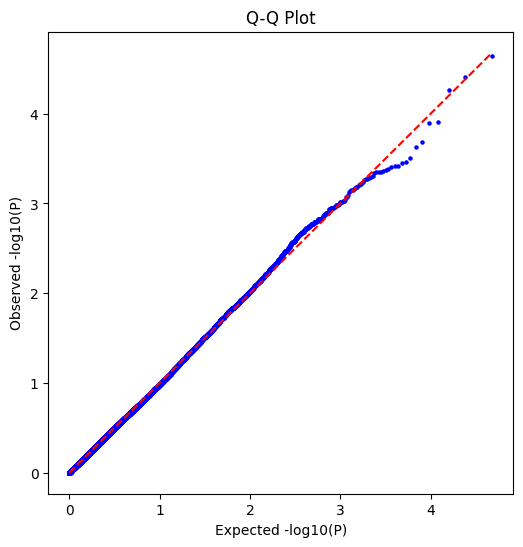

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Загрузка данных
df = pd.read_csv("/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/vcf/final_gwas_results_Yield.regenie", sep='\s+')

# 2. Подготовка координат
# Чтобы хромосомы шли друг за другом, добавим смещение
df['pos_cum'] = 0
s = 0
for i in range(1, 30): # Для коров 1-29
    df.loc[df['CHROM'] == i, 'pos_cum'] = df.loc[df['CHROM'] == i, 'GENPOS'] + s
    s += df.loc[df['CHROM'] == i, 'GENPOS'].max()

# 3. Рисуем Manhattan Plot
plt.figure(figsize=(12, 6))
colors = ['#272e38', '#7d7d7d'] # Чередующиеся цвета для хромосом
for i in range(1, 30):
    subset = df[df['CHROM'] == i]
    plt.scatter(subset['pos_cum'], subset['LOG10P'], 
                c=colors[i % 2], s=5, alpha=0.8)

# Добавляем линии порога значимости
plt.axhline(y=5, color='blue', linestyle='--', label='Suggestive') # -log10(1e-5)
plt.axhline(y=7.3, color='red', linestyle='-', label='Genome-wide') # -log10(5e-8)

# Настройка осей
plt.title("Manhattan Plot - Cattle GWAS")
plt.xlabel("Chromosome")
plt.ylabel("-log10(P)")
plt.xticks([]) # Убираем лишние цифры снизу
plt.legend()
plt.savefig("manhattan_python.png", dpi=300)
plt.show()

# 4. Рисуем Q-Q Plot (упрощенный)
plt.figure(figsize=(6, 6))
n = len(df)
expected_p = -np.log10(np.arange(1, n + 1) / n)
observed_p = sorted(df['LOG10P'], reverse=True)

plt.scatter(expected_p, observed_p, s=5, c='blue')
plt.plot([0, max(expected_p)], [0, max(expected_p)], color='red', linestyle='--')
plt.xlabel("Expected -log10(P)")
plt.ylabel("Observed -log10(P)")
plt.title("Q-Q Plot")
plt.savefig("qq_python.png", dpi=300)

In [1]:
import pandas as pd

# 1. Читаем ваш текстовый файл (предположим, он называется 'pca_results.txt')
# Если разделитель - пробелы, используем sep='\s+'
df = pd.read_csv('/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/gwas/bulls_pca.eigenvec', sep='\s+', header=None)

# 2. Создаем названия колонок
# Первые две - FID и IID, остальные - PC1, PC2...
columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, len(df.columns) - 1)]
df.columns = columns

# 3. Сохраняем в формате, который поймет REGENIE
df.to_csv('/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/vcf/covariates.txt', sep='\t', index=False)

print("Файл подготовлен: covariates.txt")
print(df.head())

Файл подготовлен: covariates.txt
                 FID                IID       PC1       PC2       PC3  \
0  HORUS003912557187  HORUS003912557187  0.005402 -0.003561  0.011784   
1  HORUS003912557068  HORUS003912557068  0.004955 -0.007344 -0.009915   
2  HORUS003910310876  HORUS003910310876 -0.001510  0.015959  0.004364   
3  HORUS003912557330  HORUS003912557330  0.018484 -0.009534 -0.011557   
4  HORUS003910310650  HORUS003910310650 -0.023864  0.008280  0.004372   

        PC4       PC5       PC6       PC7       PC8       PC9      PC10  
0  0.026156 -0.009505 -0.012624 -0.011670 -0.011748 -0.006899 -0.014213  
1 -0.000807  0.008710 -0.001289  0.008248 -0.005506 -0.005151 -0.003629  
2  0.011666  0.004890  0.005425 -0.002622 -0.007354  0.008287  0.000059  
3 -0.010148  0.022776 -0.002123 -0.004297  0.006233 -0.000727 -0.008343  
4 -0.008876 -0.006737 -0.010223 -0.003844  0.006111 -0.013394 -0.006598  


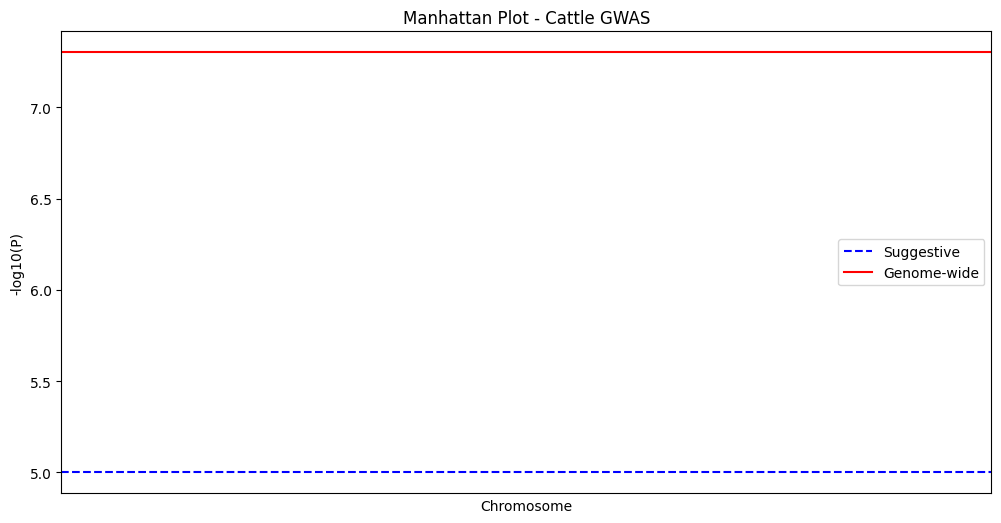

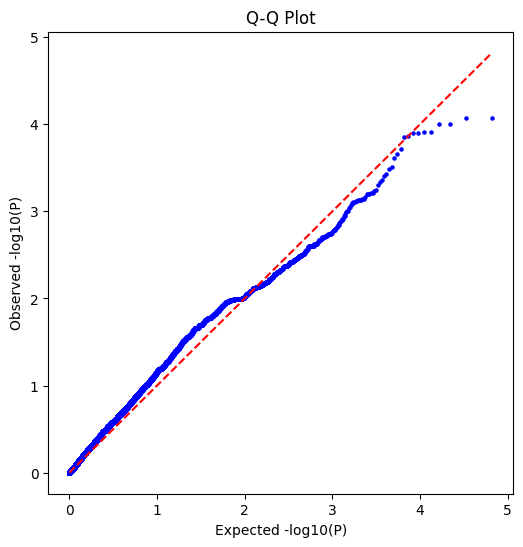

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Загрузка данных
df = pd.read_csv("/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/gwas/final_gwas_results_Yield.regenie", sep='\s+')

# 2. Подготовка координат
# Чтобы хромосомы шли друг за другом, добавим смещение
df['pos_cum'] = 0
s = 0
for i in range(1, 30): # Для коров 1-29
    df.loc[df['CHROM'] == i, 'pos_cum'] = df.loc[df['CHROM'] == i, 'GENPOS'] + s
    s += df.loc[df['CHROM'] == i, 'GENPOS'].max()

# 3. Рисуем Manhattan Plot
plt.figure(figsize=(12, 6))
colors = ['#272e38', '#7d7d7d'] # Чередующиеся цвета для хромосом
for i in range(1, 1):
    subset = df[df['CHROM'] == i]
    plt.scatter(subset['pos_cum'], subset['LOG10P'], 
                c=colors[i % 2], s=5, alpha=0.8)

# Добавляем линии порога значимости
plt.axhline(y=5, color='blue', linestyle='--', label='Suggestive') # -log10(1e-5)
plt.axhline(y=7.3, color='red', linestyle='-', label='Genome-wide') # -log10(5e-8)

# Настройка осей
plt.title("Manhattan Plot - Cattle GWAS")
plt.xlabel("Chromosome")
plt.ylabel("-log10(P)")
plt.xticks([]) # Убираем лишние цифры снизу
plt.legend()
plt.savefig("manhattan_python.png", dpi=300)
plt.show()

# 4. Рисуем Q-Q Plot (упрощенный)
plt.figure(figsize=(6, 6))
n = len(df)
expected_p = -np.log10(np.arange(1, n + 1) / n)
observed_p = sorted(df['LOG10P'], reverse=True)

plt.scatter(expected_p, observed_p, s=5, c='blue')
plt.plot([0, max(expected_p)], [0, max(expected_p)], color='red', linestyle='--')
plt.xlabel("Expected -log10(P)")
plt.ylabel("Observed -log10(P)")
plt.title("Q-Q Plot")
plt.savefig("qq_python.png", dpi=300)